# AI Human Detection Dataset Cleaning

## Objective

This notebook executes the dataset cleaning pipeline.

The cleaning process performs:

- Image validation
- RGB conversion
- JPEG conversion
- Sequential renaming
- Cleaning report generation
- Dataset verification

**Note**

This notebook only executes the pipeline.

All cleaning logic is implemented in `src/cleaning.py`.

In [1]:
from pathlib import Path
import sys
import shutil

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import importlib
import src.cleaning

importlib.reload(src.cleaning)

from src.cleaning import DatasetCleaner

In [3]:
from src.cleaning import DatasetCleaner
from src.config import (
    CLEAN_DATASET_DIR,
    METRIC_DIR,
    RAW_DATASET_DIR,
)

## Configuration

In [4]:
SOURCE_DIRECTORY = RAW_DATASET_DIR

DESTINATION_DIRECTORY = CLEAN_DATASET_DIR

REPORT_PATH = (
    METRIC_DIR /
    "cleaning_report.csv"
)

## Execute Cleaning Pipeline

In [5]:
cleaner = DatasetCleaner(
    source_dir=SOURCE_DIRECTORY,
    destination_dir=DESTINATION_DIRECTORY,
)

2026-07-11 23:02:15 | INFO     | Directory ready: C:\Users\HELGA\Documents\AI_Human_Detection\dataset_clean
2026-07-11 23:02:15 | INFO     | ======================================================================
2026-07-11 23:02:15 | INFO     | Dataset Cleaner Initialized
2026-07-11 23:02:15 | INFO     | Source      : C:\Users\HELGA\Documents\AI_Human_Detection\dataset
2026-07-11 23:02:15 | INFO     | Destination : C:\Users\HELGA\Documents\AI_Human_Detection\dataset_clean
2026-07-11 23:02:15 | INFO     | ======================================================================


In [6]:
report = cleaner.run(
    report_path=REPORT_PATH,
    clear_output=True,
)

2026-07-11 23:02:15 | INFO     | ======================================================================
2026-07-11 23:02:15 | INFO     | START CLEANING PIPELINE
2026-07-11 23:02:15 | INFO     | ======================================================================
2026-07-11 23:02:15 | INFO     | ======================================================================
2026-07-11 23:02:15 | INFO     | START DATASET CLEANING
2026-07-11 23:02:15 | INFO     | ======================================================================
2026-07-11 23:02:15 | INFO     | ======================================================================
2026-07-11 23:02:15 | INFO     | Processing class : Authentic
2026-07-11 23:02:15 | INFO     | Images found     : 739
2026-07-11 23:02:15 | INFO     | ======================================================================
 Authentic:   0%|          | 1/739 [00:00<01:37,  7.60image/s]2026-07-11 23:02:15 | INFO     | #denmark #aarhus #selfie.jpg  ->  authentic_000002

## Verification

In [7]:
summary = cleaner.export_summary()

summary

,total_images,processed_images,unreadable_images,failed_images
0,1525,1525,0,0


In [8]:
distribution = cleaner.export_distribution()

distribution

,class,images
0,Authentic,739
1,AI,786


In [9]:
report.head()

,original_filename,new_filename,class_name,status,width,height,format,mode,aspect_ratio,size_kb,md5
0,023d6f6f-06ff-4628-b1f5-b79a616758d5.png,ai_000001.jpg,AI,SUCCESS,886,1775,PNG,RGB,0.499,367.69,8aa80e125acb6f4a400084ca774dafe6
1,02d4a3d4-703d-4668-b606-3599165acda8.png,ai_000002.jpg,AI,SUCCESS,941,1670,PNG,RGB,0.563,249.51,76d900c69544930e901b3b53b16c9c7a
2,04e46894-6b2c-4d42-803e-2e08d6341009.png,ai_000003.jpg,AI,SUCCESS,1024,1536,PNG,RGB,0.667,522.62,9cfbbb7daccdc49f061848f4d63ccbae
3,0549007c-7a55-4619-b352-ba7a7d80e3a2.png,ai_000004.jpg,AI,SUCCESS,941,1672,PNG,RGB,0.563,384.07,38da85efc1b6f9e3961543a2186595eb
4,07cc5a50-d6fb-4713-ab78-8880291ec844.png,ai_000005.jpg,AI,SUCCESS,853,1844,PNG,RGB,0.463,404.39,73adb637814c3debbdcab9fce594b91d


In [10]:
report.sample(
    min(
        10,
        len(report),
    )
)

,original_filename,new_filename,class_name,status,width,height,format,mode,aspect_ratio,size_kb,md5
925,1805583390_6d7b8267b6_z.jpg,authentic_000140.jpg,Authentic,SUCCESS,640,480,JPEG,RGB,1.333,69.92,65a0034bf53ebf0a35033087f6a7b160
824,0f700bdb49dcdd6c.jpg,authentic_000039.jpg,Authentic,SUCCESS,1024,768,JPEG,RGB,1.333,227.24,63737f35adcd6acee431c6ddefe2f0e9
1389,gnbhhb.jpg,authentic_000604.jpg,Authentic,SUCCESS,1200,800,JPEG,RGB,1.500,218.56,25e4e1674609d06c76561355a8dc0d3b
1353,FB_IMG_1783781433602.jpg,authentic_000568.jpg,Authentic,SUCCESS,2048,1536,JPEG,RGB,1.333,886.07,dc7a663bab162f8eb62913b09ef9fdd2
1442,paje-victoria-Dlnbpou4ES8-unsplash-1-scaled.jpg,authentic_000657.jpg,Authentic,SUCCESS,1000,667,JPEG,RGB,1.499,309.98,3f85763a1894b343e6b26fb65cebe9f4
414,"ChatGPT Image Jul 2, 2026, 10_08_01 PM.png",ai_000415.jpg,AI,SUCCESS,1536,1024,PNG,RGB,1.500,432.16,ef55285e945c610d37f0f57f2773c9e0
249,"ChatGPT Image Jul 2, 2026, 01_15_06 PM.png",ai_000250.jpg,AI,SUCCESS,1086,1448,PNG,RGB,0.750,263.91,9d62efe5f35ab758bdb949beea3397dc
754,file_00000000772472098af3027555667f50~5.png,ai_000755.jpg,AI,SUCCESS,238,306,JPEG,RGB,0.778,19.88,8c1b08395348a25bfe57e265c859f061
135,"ChatGPT Image Jul 1, 2026, 10_45_14 PM.png",ai_000136.jpg,AI,SUCCESS,1448,1086,PNG,RGB,1.333,483.64,75121644be60d9218de83134b0d8e16c
1461,Screenshot_2026-07-11-21-26-10-244_com.faceboo...,authentic_000676.jpg,Authentic,SUCCESS,1080,2400,JPEG,RGB,0.450,715.42,5e0dac1607e3614e34b800146930a589


## Visualization

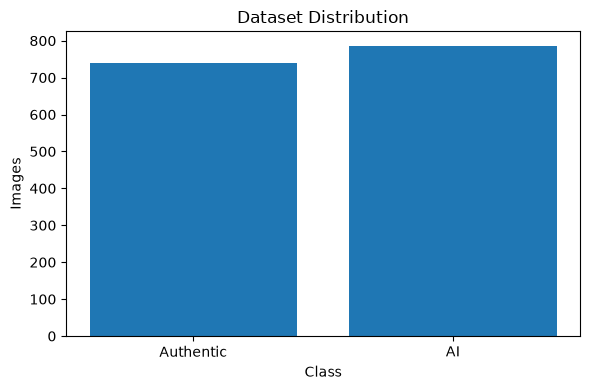

In [11]:
import matplotlib.pyplot as plt

figure = plt.figure(
    figsize=(6, 4),
)

plt.bar(
    distribution["class"],
    distribution["images"],
)

plt.title("Dataset Distribution")

plt.xlabel("Class")

plt.ylabel("Images")

plt.tight_layout()

plt.show()

In [12]:
REPORT_PATH.exists()

True

## Conclusion

The dataset cleaning pipeline successfully:

- validated all readable images,
- converted images into RGB,
- saved all images as JPEG,
- renamed images sequentially,
- generated the cleaning report,
- verified the cleaned dataset.

The cleaned dataset is now ready for preprocessing.